## Validation of recalculation of mean velocity of a certain time interval

For the recalculation of the mean velocity for e.g. 2022-01-01 till 2024-12-31 a linear regression was performed on the time series. The slope represents the mean velocity for that time range.

In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Set data directories

In [2]:
augmenterra_data_dir = Path("/home/lukas/projects/ADUCAT/data/Augmenterra/processed")
egms_data_dir = Path("/home/lukas/projects/ADUCAT/data/EGMS/vienna/processed")

orbit_direction = "ASC"
orbit = "073"

ref_augmenterra_file = Path(augmenterra_data_dir, f"VIENNA_TUNNELLING_velocity_{orbit_direction}.parquet")
print("Augmenterra reference data file:", ref_augmenterra_file)

ref_egms_file = Path(egms_data_dir, f"EGMS_{orbit}_2020_2024.parquet")
print("EGMS reference data file:", ref_egms_file)

Augmenterra reference data file: /home/lukas/projects/ADUCAT/data/Augmenterra/processed/VIENNA_TUNNELLING_velocity_ASC.parquet
EGMS reference data file: /home/lukas/projects/ADUCAT/data/EGMS/vienna/processed/EGMS_073_2020_2024.parquet


### Augmenterra

In [7]:
# ============================================================
# Columns to load
# ============================================================

AUGMENTERRA_VEL_orig = "VEL"
AUGMENTERRA_VEL_calculated = "VEL_20190101_20260430"

augmenterra_cols = [
    AUGMENTERRA_VEL_orig,
    AUGMENTERRA_VEL_calculated
]

augmenterra = pd.read_parquet(
    ref_augmenterra_file,
    columns=augmenterra_cols
)

print(augmenterra.head())


   VEL  VEL_20190101_20260430
0 -0.4                   -0.4
1  0.2                    0.2
2  0.1                    0.1
3 -0.9                   -0.9
4 -0.0                   -0.0


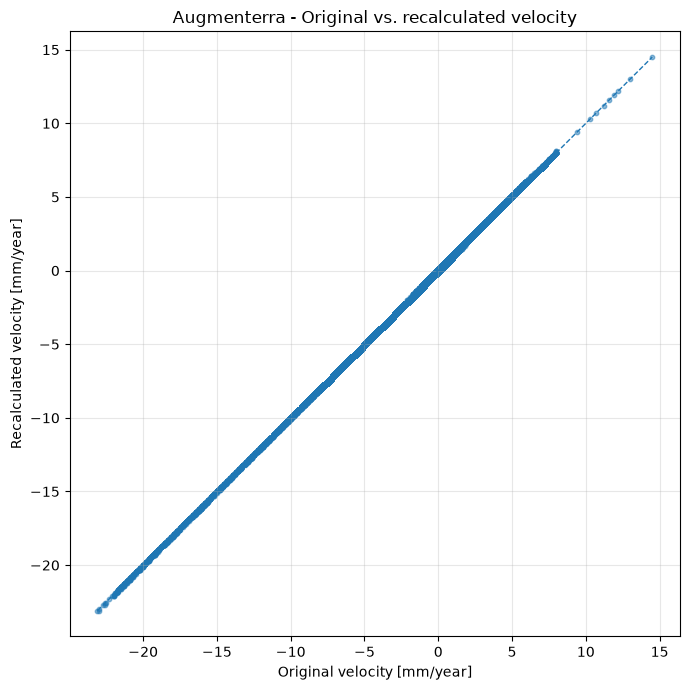

In [16]:
plt.figure(figsize=(7, 7))

plt.scatter(
    augmenterra["VEL"],
    augmenterra["VEL_20190101_20260430"],
    s=10,
    alpha=0.5
)

# 1:1 reference line
lims = [
    min(augmenterra["VEL"].min(), augmenterra["VEL_20190101_20260430"].min()),
    max(augmenterra["VEL"].max(), augmenterra["VEL_20190101_20260430"].max())
]

plt.plot(lims, lims, "--", linewidth=1)

plt.xlabel("Original velocity [mm/year]")
plt.ylabel("Recalculated velocity [mm/year]")
plt.title("Augmenterra - Original vs. recalculated velocity")

plt.grid(alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.show()

In [11]:
comparison = augmenterra[["VEL", "VEL_20190101_20260430"]].dropna()

x = comparison["VEL"]
y = comparison["VEL_20190101_20260430"]

correlation = x.corr(y)
rmse = np.sqrt(np.mean((x - y) ** 2))
mae = np.mean(np.abs(x - y))

print(f"Correlation: {correlation:.3f}")
print(f"RMSE:        {rmse:.3f} mm/year")
print(f"MAE:         {mae:.3f} mm/year")

Correlation: 1.000
RMSE:        0.009 mm/year
MAE:         0.001 mm/year


### EGMS data

In [12]:
# ============================================================
# Columns to load
# ============================================================

EGMS_VEL_orig = "mean_velocity"
EGMS_VEL_calculated = "VEL_20200101_20241231"

egms_cols = [
    EGMS_VEL_orig,
    EGMS_VEL_calculated
]

egms = pd.read_parquet(
    ref_egms_file,
    columns=egms_cols
)

print(egms.head())

   mean_velocity  VEL_20200101_20241231
0            0.3                    0.3
1            0.0                   -0.0
2            0.4                    0.4
3            0.2                    0.3
4            0.1                    0.1


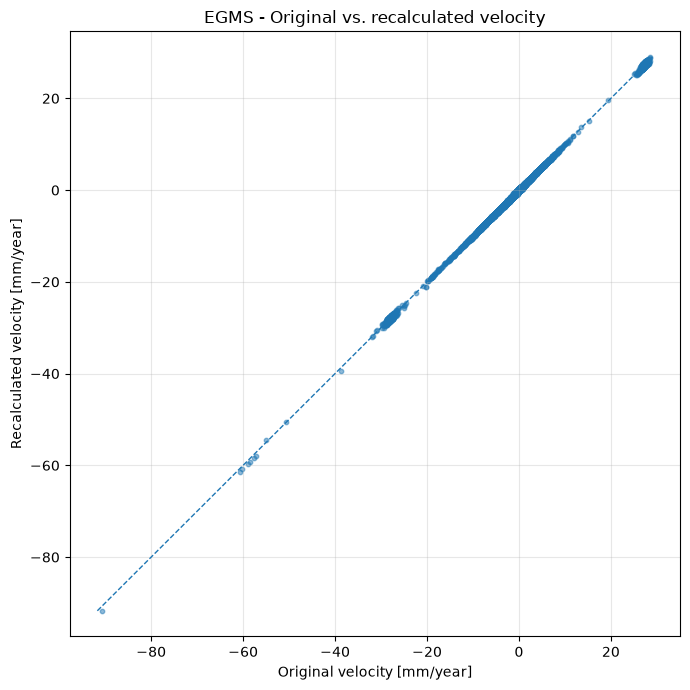

In [15]:
plt.figure(figsize=(7, 7))

plt.scatter(
    egms["mean_velocity"],
    egms["VEL_20200101_20241231"],
    s=10,
    alpha=0.5
)

# 1:1 reference line
lims = [
    min(egms["mean_velocity"].min(), egms["VEL_20200101_20241231"].min()),
    max(egms["mean_velocity"].max(), egms["VEL_20200101_20241231"].max())
]

plt.plot(lims, lims, "--", linewidth=1)

plt.xlabel("Original velocity [mm/year]")
plt.ylabel("Recalculated velocity [mm/year]")
plt.title("EGMS - Original vs. recalculated velocity")

plt.grid(alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.show()

In [14]:
comparison = egms[["mean_velocity", "VEL_20200101_20241231"]].dropna()

x = comparison["mean_velocity"]
y = comparison["VEL_20200101_20241231"]

correlation = x.corr(y)
rmse = np.sqrt(np.mean((x - y) ** 2))
mae = np.mean(np.abs(x - y))

print(f"Correlation: {correlation:.3f}")
print(f"RMSE:        {rmse:.3f} mm/year")
print(f"MAE:         {mae:.3f} mm/year")

Correlation: 0.998
RMSE:        0.062 mm/year
MAE:         0.035 mm/year
